# Analysis of the results

#### Setting up the environment

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics as stats

#### Results import

In [11]:
heuristics = ["FCFS", "LCFS", "SJF","LJF","RR","LBW","WS"]
variances = [0.0000, 0.0010, 0.0017, 0.0030, 0.0044, 0.0065, 0.0095, 0.0138, 0.0201, 0.0292, 0.0425, 0.0619, 0.0901, 0.1311, 0.1908, 0.2772, 0.4026, 0.5848, 0.8496, 1.0000]
n_v = len(variances)

taskData = {}

In [12]:
Tdata = [[[] for j in range(n_v)] for i in range(7)]
Wdata = [[[] for j in range(n_v)] for i in range(7)]
Sdata = [0 for i in range(7)]
for h_id in range(7): #per heuristic
    for v_id in range(n_v): #per test set / variance parameter
        with open(f"../results/{h_id}_{v_id}.txt", mode='r') as f:
            raw = f.readlines()

        worker_lines = []
        for line in raw:
            if line[0] == 'W':
                Wdata[h_id][v_id].append((float(line.split(sep=';')[2][2:].strip('\n')), 
                                      float(line.split(sep=';')[1][2:]))) #add tuple (task time, overhead)
            elif line[0] == 'M':
                Sdata[h_id] = float(line.split(':')[1]) #add makespan
            elif line[0] == 'T':
                Tdata[h_id][v_id].append((float(line.split(';')[0][2:]), #Task ID
                                          float(line.split(';')[1][2:]), #Worker ID
                                          float(line.split(';')[2][2:]), #Task time
                                          line.split(';')[3][2:])) #Queue time
        worker_lines.sort()
        
n_worker = len(Wdata[0][0])


In [13]:
std_tasks = {heuristic: [] for heuristic in heuristics}
avg_tasks = {heuristic: [] for heuristic in heuristics}
for h_id, heuristic in enumerate(heuristics):
    for v_id in range(n_v):
        tasks = [entry[0] for entry in Wdata[h_id][v_id]]
        std_tasks[heuristic].append(np.std(tasks))
        avg_tasks[heuristic].append(np.mean(tasks))

std_overheads = {heuristic: [] for heuristic in heuristics}
avg_overheads = {heuristic: [] for heuristic in heuristics}
for h_id, heuristic in enumerate(heuristics):
    for v_id in range(n_v):
        overheads = [entry[1] for entry in Wdata[h_id][v_id]]
        std_overheads[heuristic].append(np.std(overheads))
        avg_overheads[heuristic].append(np.mean(overheads))

Wdata: Worker data, Wdata[Heuristic][Variance][worker] = (total task time, overhead)

Tdata: Task data, Tdata[Heuristic][Variance] = [task times]

### Graph Generation

In [5]:
colors = {'FCFS':'blue', 'LCFS':'green', 'SJF':'red', 'LJF':'purple', 'RR':'orange', 'LBW':'cyan', 'WS':'magenta'}

figSize = {'S':(12,6), 'M':(12,7), 'L':(12,8)}

##### Logarithmic scaling parameters

In [47]:
logLinthresh = 0.001
logLinscale = 0.17

#### 1. Overhead Growth Patterns per Heuristic (Scalability under Variance)

**Phenomenon:**
All heuristics exhibit overhead increase with higher variance, but SJF (Shortest Job First) and LJF (Longest Job First) show more stable overheads compared to FCFS, LCFS, and RR at mid-range variances (0.056–0.31). RR displays the most erratic overhead spikes.

**Visualization:**
Line Chart: X-axis: Variance, Y-axis: Average Overhead per Heuristic.
Highlight "stability zones" (variance intervals where overhead growth is minimal).
RR's spike at variance=0.31 and 0.56 can be annotated.

**Interpretation:**
SJF and LJF heuristics demonstrate superior scalability under moderate workload variances. RR's performance becomes unpredictable under higher variance, indicating poor load-balancing resilience.

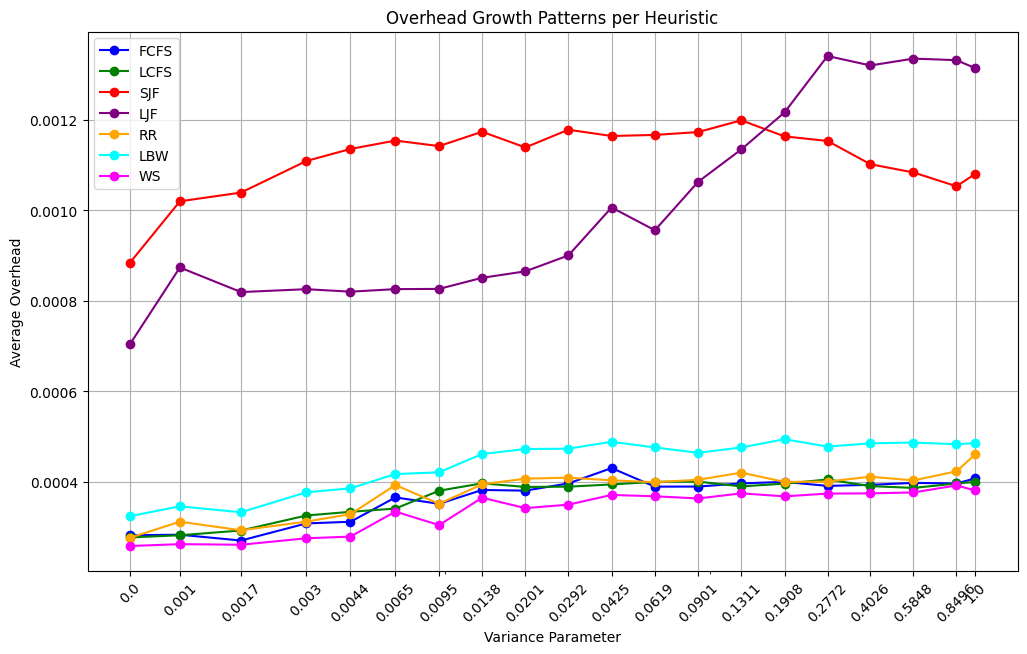

In [57]:
# Plotting
plt.figure(figsize=figSize['M'])
for heuristic in heuristics:
    plt.plot(variances, avg_overheads[heuristic], label=heuristic, marker='o', color=colors[heuristic])

plt.xlabel('Variance Parameter')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel('Average Overhead')
plt.title('Overhead Growth Patterns per Heuristic')
plt.legend()
plt.grid(True)
plt.show()

#### 2. Task Time Distribution Clustering per Heuristic

**Phenomenon:**
Heuristics like SJF consistently allocate longer task times to initial workers compared to FCFS, LCFS, and WS, indicating a deliberate front-loading of execution-heavy tasks.

**Visualization:**
Boxplots per Heuristic: X-axis: Worker Index, Y-axis: Task Time.
Separate subplots for SJF vs. FCFS/LCFS/WS for clearer contrast.

**Interpretation:**
SJF's front-loaded task time distribution reflects its design principle of minimizing global execution time but could lead to worker under-utilization in dynamic environments.

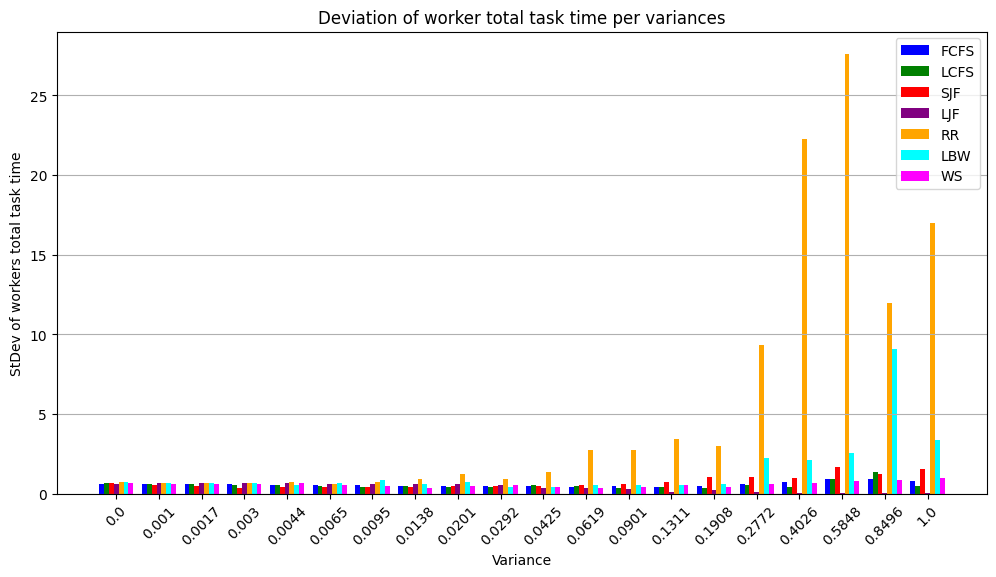

In [58]:
bar_width = 0.8/len(heuristics)

x = np.arange(len(variances))

series = [[stats.stdev([Wdata[h_id][v_id][i][0] for i in range(n_worker)]) for v_id in range(len(variances))] for h_id in range(len(heuristics))]

plt.figure(figsize=figSize['S'])
for h_id, heuristic in enumerate(heuristics):
    offset = (h_id - len(heuristics)/2) * bar_width + bar_width/2
    plt.bar(x + offset, series[h_id], width=bar_width, label=heuristic, color=colors[heuristic])

plt.xlabel('Variance')
plt.xticks(x, variances, rotation=45)
plt.ylabel('StDev of workers total task time')
plt.title(f'Deviation of worker total task time per variances')
plt.legend()
plt.grid(axis='y')
plt.show()

In [ ]:
#Add the boxplots for the most interesting ones here

#Can't do the real one yet, need to restart while registering which task for which worker when printing out task time

#### 3. Load-Balancing Heuristics (LBW, WS) Mitigate Overhead but at Task Time Cost

**Phenomenon:**
LBW and WS maintain low variance in overhead growth, but they assign consistently longer task times to individual tasks compared to FCFS/LCFS.

**Visualization:**
Scatter Plot: X-axis: Task Time, Y-axis: Overhead per Task, color-coded by Heuristic.
Trendlines for LBW/WS vs. FCFS/LCFS.

**Interpretation:**
Load-balancing heuristics effectively distribute overhead but do so at the cost of task time efficiency, reflecting a trade-off between execution speed per task and overall system balance.

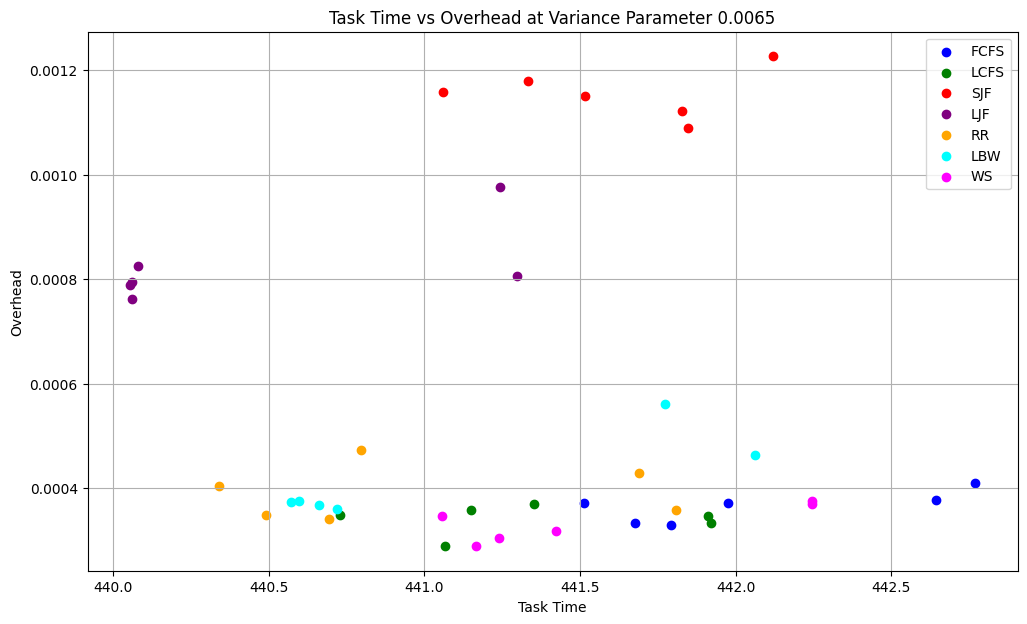

In [30]:
# Extract data for Variance Parameter = 0.1 (v_id = 5)
v_id = 5
task_times = []
overheads = []
labels = []

for h_id, heuristic in enumerate(heuristics):
    for task_time, overhead in Wdata[h_id][v_id]:
        task_times.append(task_time)
        overheads.append(overhead)
        labels.append(heuristic)

#Plotting

plt.figure(figsize=figSize['M'])
for heuristic in heuristics:
    xs = [t for t, h in zip(task_times, labels) if h == heuristic]
    ys = [o for o, h in zip(overheads, labels) if h == heuristic]
    plt.scatter(xs, ys, label=heuristic, color=colors[heuristic])

plt.xlabel('Task Time')
plt.ylabel('Overhead')
plt.title(f'Task Time vs Overhead at Variance Parameter {variances[v_id]}')
plt.legend()
plt.grid(True)
plt.show()

#### 4. RR Heuristic Exhibits Variance Sensitivity and Scheduling Instability

**Phenomenon:**
RR shows significant deviations in overhead (overhead spikes at variance = 0.31, 0.56, 1.0), unlike other heuristics which show smoother overhead increases.

**Visualization:**
Variance vs. Overhead Variance Plot (Error Bars): X-axis: Variance, Y-axis: Standard Deviation of Overhead across Workers, for RR vs. others.

**Interpretation:**
Round Robin's simplistic scheduling fails under high workload variability, making it unsuitable for environments with unpredictable task profiles.

##### Task Time Variability

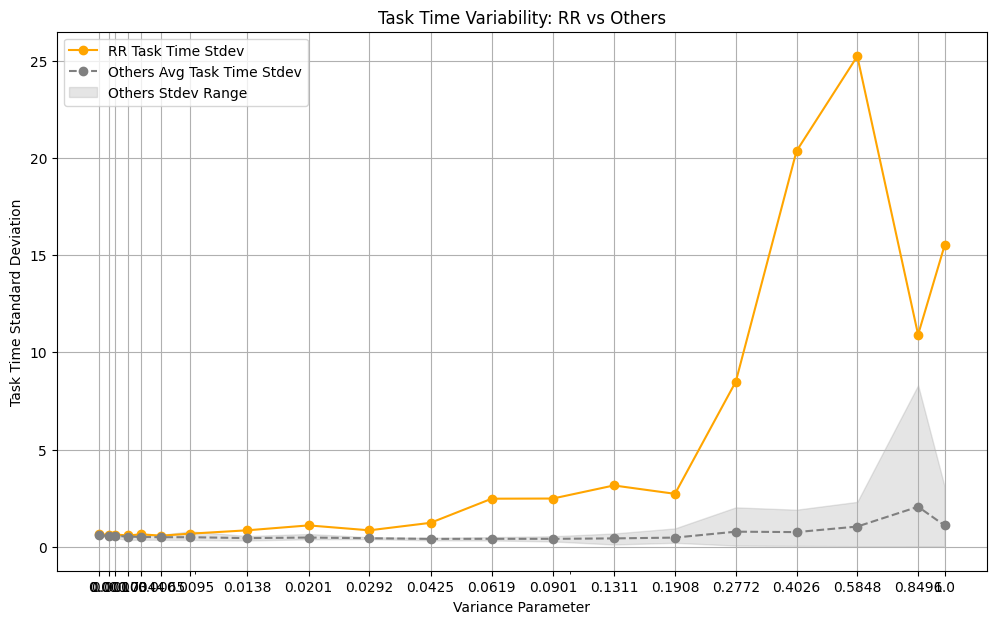

In [32]:
# Plotting Subplots
plt.figure(figsize=figSize['M'])


# Left subplot: Task Time Standard Deviation (Shaded Zone for Others)
rr_std = std_tasks['RR']
others_min_std = []
others_max_std = []
others_avg_std = []

for v_id in range(n_v):
    other_stds = [std_tasks[heuristic][v_id] for heuristic in heuristics if heuristic != 'RR']
    avg_std = np.mean(other_stds)
    others_avg_std.append(avg_std)
    others_min_std.append(np.min(other_stds))
    others_max_std.append(np.max(other_stds))

# Left subplot: Task Time Standard Deviation
plt.plot(variances, rr_std, label='RR Task Time Stdev', marker='o', color='orange')
plt.plot(variances, others_avg_std, label='Others Avg Task Time Stdev', marker='o', linestyle='--', color='gray')
plt.fill_between(variances, others_min_std, others_max_std, color='gray', alpha=0.2, label='Others Stdev Range')
plt.xlabel('Variance Parameter')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False)
plt.ylabel('Task Time Standard Deviation')
plt.title('Task Time Variability: RR vs Others')
plt.legend()
plt.grid(True)


plt.show()


##### Overhead Variability

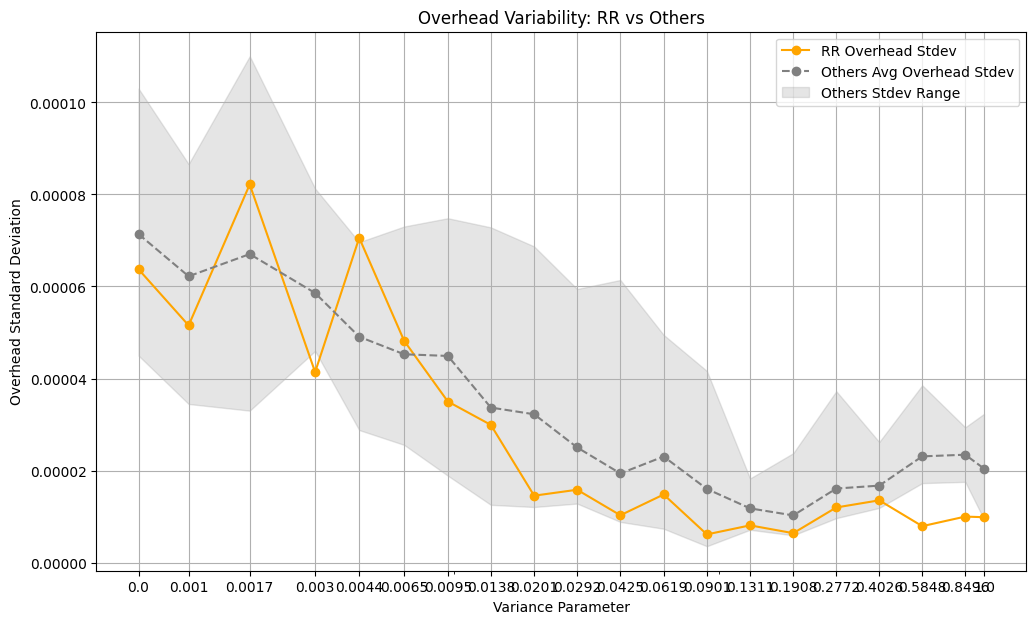

In [59]:
# Plot RR vs Average of Others
rr_std = std_overheads['RR']
others_avg_std = []
others_min_std = []
others_max_std = []

for v_id in range(n_v):
    other_stds = [std_overheads[heuristic][v_id] for heuristic in heuristics if heuristic != 'RR']
    others_min_std.append(np.min(other_stds))
    others_max_std.append(np.max(other_stds))
    avg_std = np.mean(other_stds)
    others_avg_std.append(avg_std)

plt.figure(figsize=figSize['M'])

plt.plot(variances, rr_std, label='RR Overhead Stdev', marker='o', color='orange')
plt.plot(variances, others_avg_std, label='Others Avg Overhead Stdev', marker='o', linestyle='--', color='gray')
plt.fill_between(variances, others_min_std, others_max_std, color='gray', alpha=0.2, label='Others Stdev Range')
plt.xlabel('Variance Parameter')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False)
plt.ylabel('Overhead Standard Deviation')
plt.title('Overhead Variability: RR vs Others')
plt.legend()
plt.grid(True)

plt.show()

##### Task time per worker RR

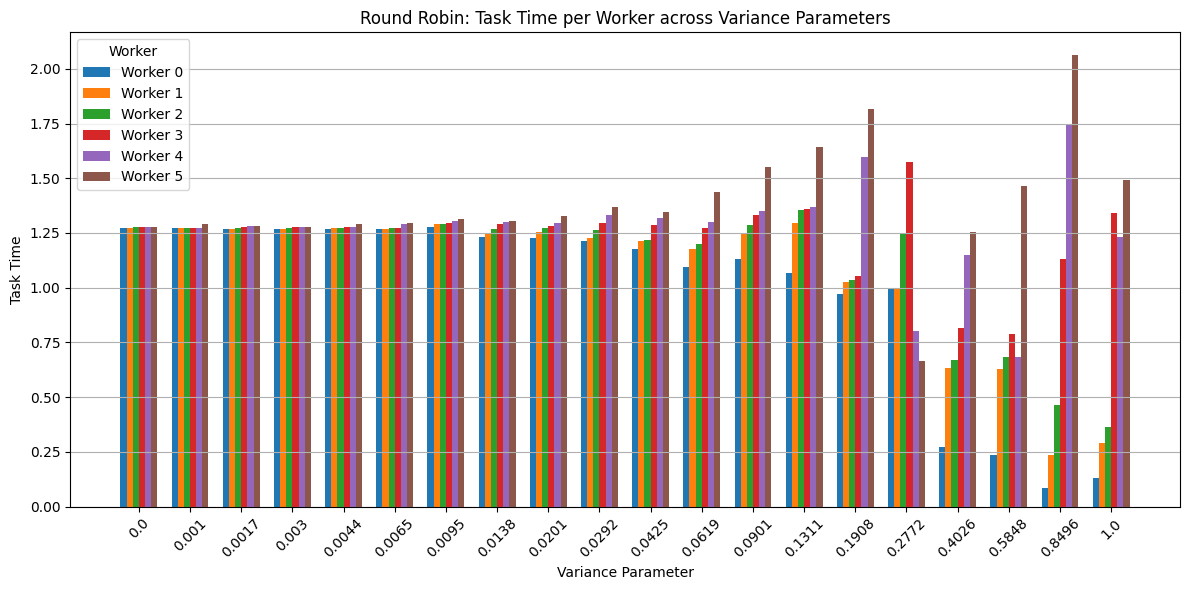

In [60]:
# Extract RR task times
rr_task_times = Tdata[4]  # Shape: [variance_id][worker_id]

# Grouped Bar Plot
bar_width = 0.12
x = np.arange(n_v)  # Base positions for each variance group

plt.figure(figsize=figSize['S'])

for worker_id in range(n_worker):
    worker_times = [rr_task_times[v_id][worker_id][2] for v_id in range(n_v)]
    offset = (worker_id - (n_worker - 1) / 2) * bar_width
    plt.bar(x + offset, worker_times, width=bar_width, label=f'Worker {worker_id}')

# Formatting
plt.xticks(ticks=x, labels=variances, rotation=45)
plt.xlabel('Variance Parameter')
plt.ylabel('Task Time')
plt.title('Round Robin: Task Time per Worker across Variance Parameters')
plt.legend(title='Worker')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

#### 5. Divergence of FCFS and LCFS under High Variance
Phenomenon:
At low variances, FCFS and LCFS are nearly identical in overhead and task time distributions. At higher variances (≥ 0.56), LCFS starts performing slightly better in overhead, suggesting a divergence in their load-balancing efficiency.

Visualization:
Dual Line Chart: X-axis: Variance, Y-axis: Average Overhead, separate lines for FCFS and LCFS.
Highlight divergence regions with annotations.

Interpretation:
Though similar in design, LCFS demonstrates a marginal advantage in handling high-variance workloads, likely due to its implicit adaptation to newer task influxes.

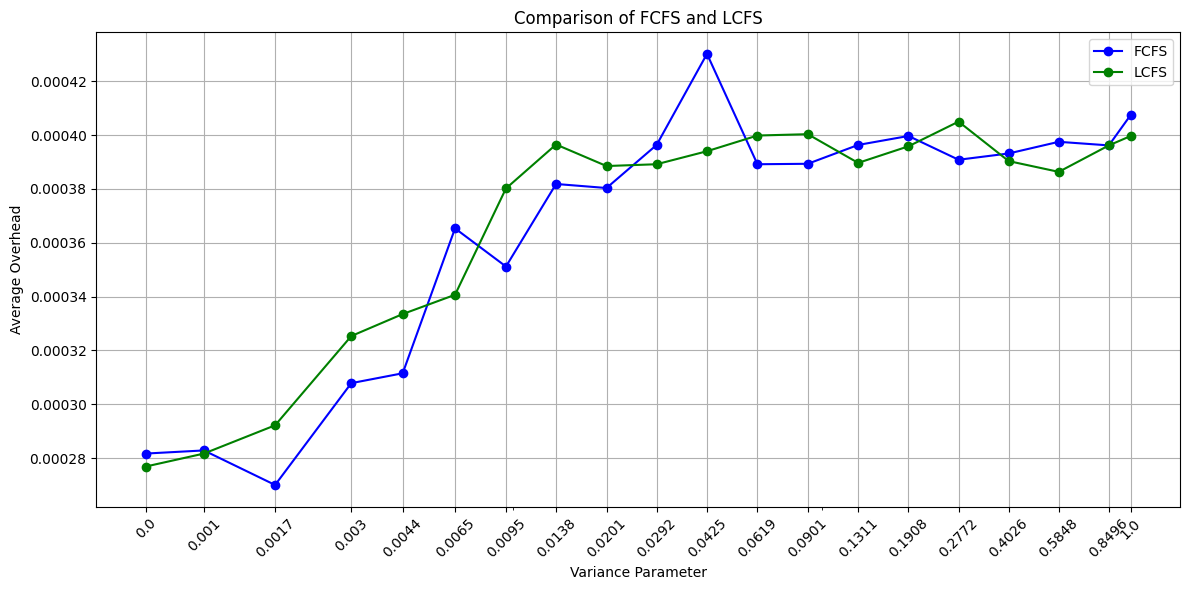

In [61]:
fcfs_avg_overhead = []
lcfs_avg_overhead = []

for v_id in range(n_v):
    fcfs_oh = [pair[1] for pair in Wdata[0][v_id]]
    lcfs_oh = [pair[1] for pair in Wdata[1][v_id]]
    fcfs_avg_overhead.append(np.mean(fcfs_oh))
    lcfs_avg_overhead.append(np.mean(lcfs_oh))

# Plotting
plt.figure(figsize=figSize['S'])
plt.plot(variances, fcfs_avg_overhead, label='FCFS', marker='o', color=colors['FCFS'])
plt.plot(variances, lcfs_avg_overhead, label='LCFS', marker='o', color=colors['LCFS'])


plt.xlabel('Variance Parameter')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel('Average Overhead')
plt.title('Comparison of FCFS and LCFS')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 6. Longest Job First (LJF) Shows Anomalous Stability in High Variance Overhead
Phenomenon:
LJF maintains nearly constant overhead increases, even as variance grows, outperforming expectation given its theoretical scheduling bias towards large tasks.

Visualization:
Line Chart Overlay: X-axis: Variance, Y-axis: Average Overhead for LJF vs. other heuristics.
Confidence bands around LJF’s line to visualize its low variance.

Interpretation:
LJF's unexpected stability suggests that prioritizing heavier tasks might inherently absorb variance-induced scheduling noise, making it a robust strategy in high-load systems.

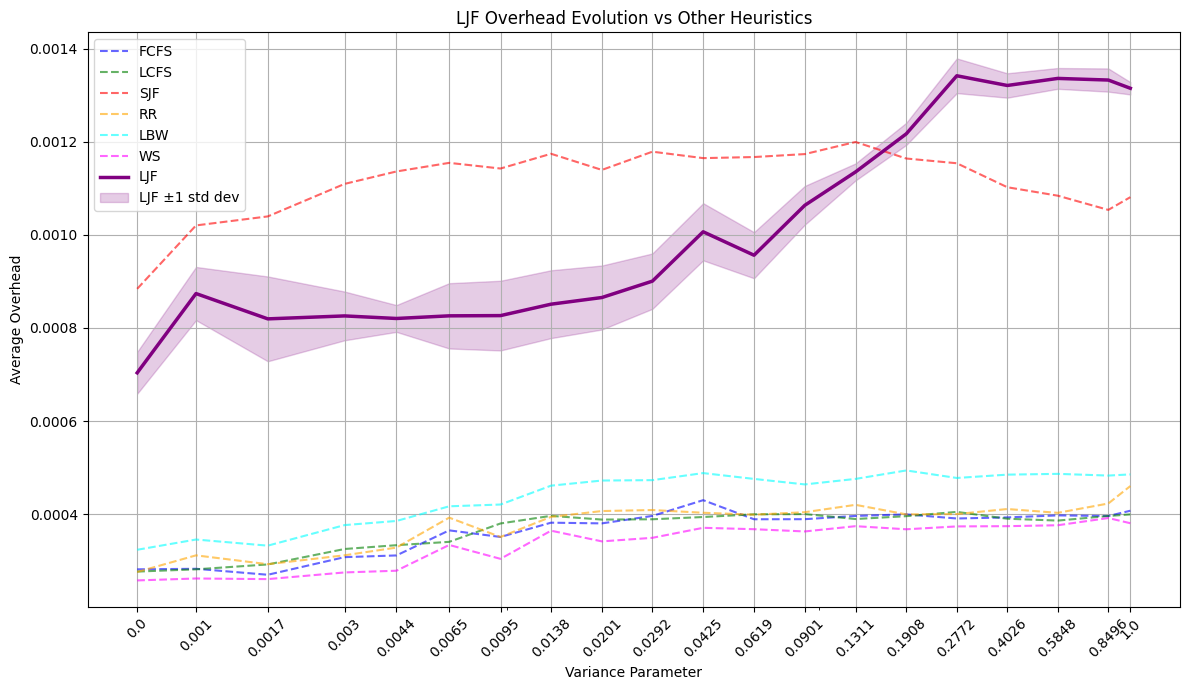

In [62]:
# Plotting
plt.figure(figsize=figSize['M'])

# Plot other heuristics
for heuristic in heuristics:
    if heuristic != 'LJF':
        plt.plot(variances, avg_overheads[heuristic], label=heuristic, linestyle='--', alpha=0.6, color=colors[heuristic])

# Plot LJF with confidence band
ljf_avg = avg_overheads['LJF']
ljf_std = std_overheads['LJF']
ljf_upper = [m + s for m, s in zip(ljf_avg, ljf_std)]
ljf_lower = [m - s for m, s in zip(ljf_avg, ljf_std)]

plt.plot(variances, ljf_avg, label='LJF', color=colors['LJF'], linewidth=2.5)
plt.fill_between(variances, ljf_lower, ljf_upper, color=colors['LJF'], alpha=0.2, label='LJF ±1 std dev')

# Formatting
plt.xlabel('Variance Parameter')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel('Average Overhead')
plt.title('LJF Overhead Evolution vs Other Heuristics')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### 8. Worst case worker performance

what: max overhead of workers per heuristic per variance

why: Highlights if a heuristic consistently creates bottlenecks

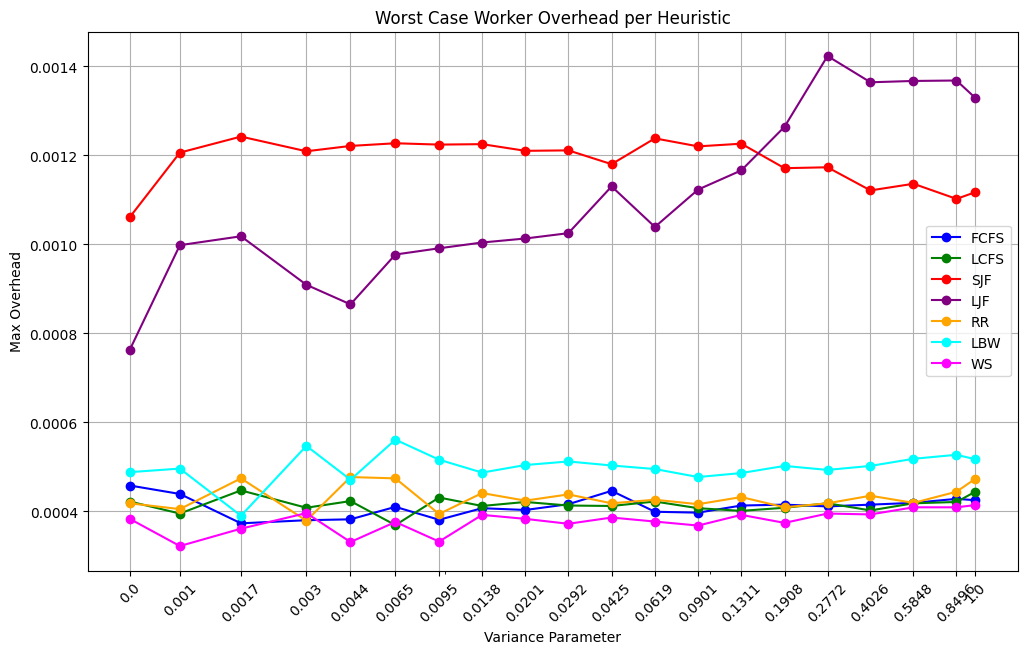

In [63]:
max_overheads = {heuristic: [] for heuristic in heuristics}
for h_id, heuristic in enumerate(heuristics):
    for v_id in range(n_v):
        overheads = [entry[1] for entry in Wdata[h_id][v_id]]
        max_overheads[heuristic].append(np.max(overheads))

plt.figure(figsize=figSize['M'])
for heuristic in heuristics:
    plt.plot(variances, max_overheads[heuristic], label=heuristic, marker='o', color=colors[heuristic])
plt.xlabel('Variance Parameter')
plt.xscale('symlog', linthresh=logLinthresh, linscale=logLinscale)
plt.xticks(variances, labels=variances, minor=False, rotation=45)
plt.ylabel('Max Overhead')
plt.title('Worst Case Worker Overhead per Heuristic')
plt.legend()
plt.grid(True)
plt.show()

#### 9. Lost worker time

We consider time lost when a worker is done and waiting for other workers to finish to close.

= sum of (makespan - finish time) per worker for all workers

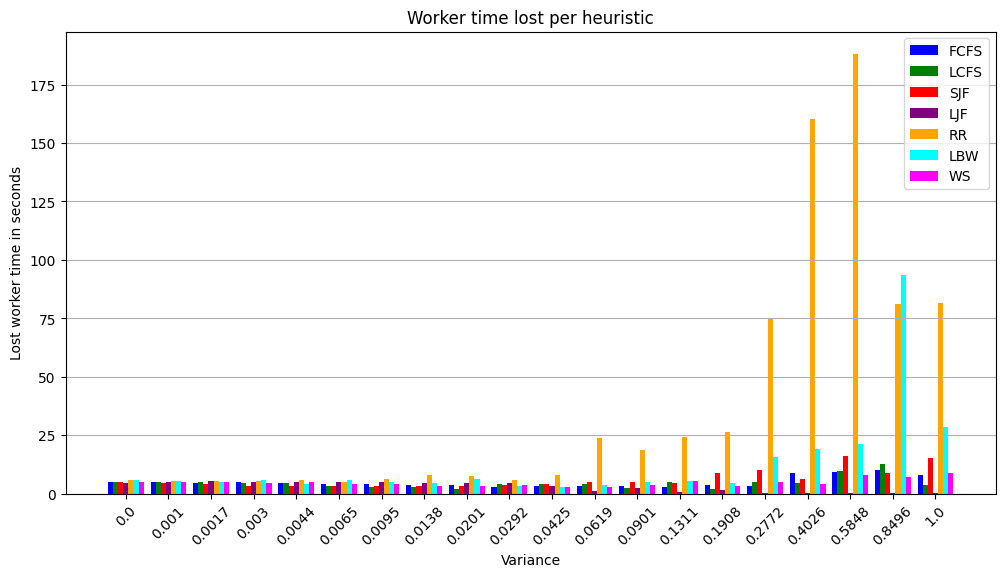

In [42]:
lost_time = {heuristic: [] for heuristic in heuristics}
for h_id, heuristic in enumerate(heuristics):
    for v_id in range(n_v):
        makespan = max([entry[0] for entry in Wdata[h_id][v_id]]) #Max worker task time
        total_lost = sum(makespan - entry[0] for entry in Wdata[h_id][v_id]) #Sum of (makespan - worker task time)
        lost_time[heuristic].append(total_lost)

plt.figure(figsize=figSize['S'])

for h_id, heuristic in enumerate(heuristics):
    offset = (h_id - len(heuristics)/2) * bar_width + bar_width/2
    plt.bar(x + offset, lost_time[heuristic], width=bar_width, label=heuristic, color=colors[heuristic])

plt.xlabel('Variance')
plt.xticks(x, variances, minor=False, rotation=45)
plt.ylabel('Lost worker time in seconds')
plt.title(f'Worker time lost per heuristic')
plt.legend()
plt.grid(axis='y')
plt.show()
